# Eksperimen_AnggaMaulana
## Mall Customer Segmentation — Clustering Pipeline
**Kelas:** Membangun Sistem Machine Learning  
**Dataset:** Mall Customer Segmentation (Kaggle)  
**Algoritma:** K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
# Load dataset
df = pd.read_csv('../mall_customers_raw/Mall_Customers.csv')

print(f"✅ Dataset berhasil dimuat")
print(f"Shape : {df.shape}")
print(f"Kolom : {list(df.columns)}")
df.head(10)

✅ Dataset berhasil dimuat
Shape : (200, 5)
Kolom : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
df.info()
print()
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

STATISTIK DESKRIPTIF


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
print("Missing Values per Kolom:")
print(df.isnull().sum())
print()
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print()
print("Distribusi Gender:")
print(df['Gender'].value_counts())

Missing Values per Kolom:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Jumlah baris duplikat: 0

Distribusi Gender:
Gender
Female    112
Male       88
Name: count, dtype: int64


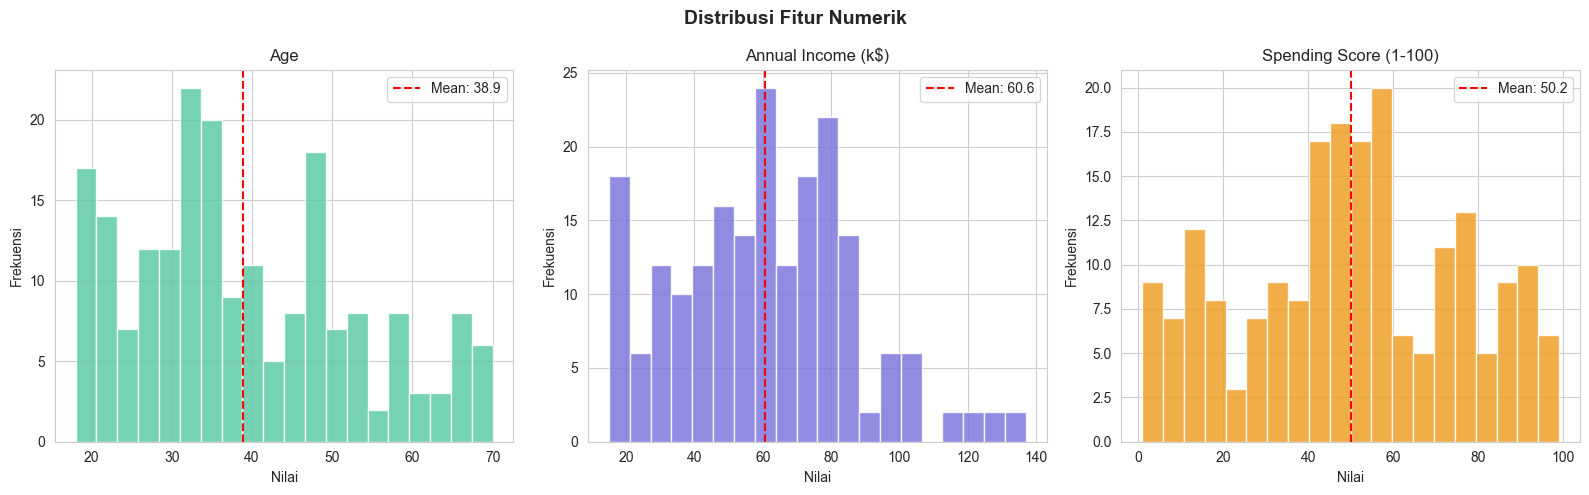

✅ Plot distribusi tersimpan


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')

numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#5DCAA5', '#7F77DD', '#EF9F27']

for ax, col, color in zip(axes, numerical_cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot distribusi tersimpan")

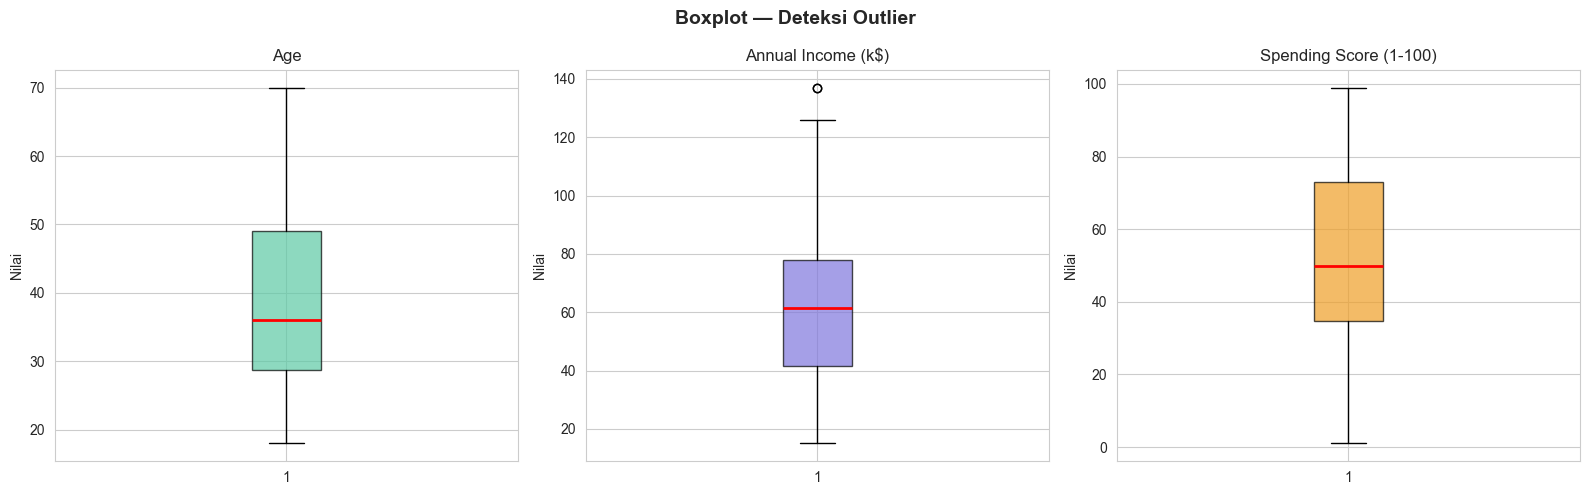

✅ Boxplot tersimpan


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplot — Deteksi Outlier', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, numerical_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
    ax.set_ylabel('Nilai')

plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplot tersimpan")

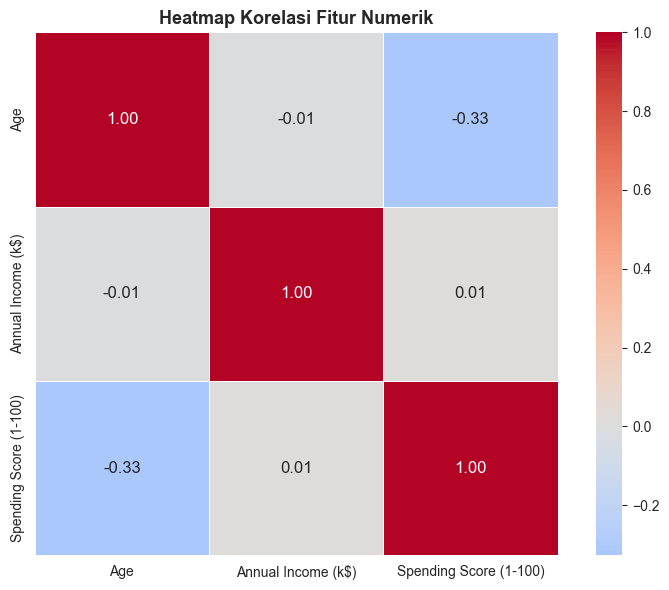

✅ Heatmap tersimpan


In [7]:
plt.figure(figsize=(8, 6))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap tersimpan")

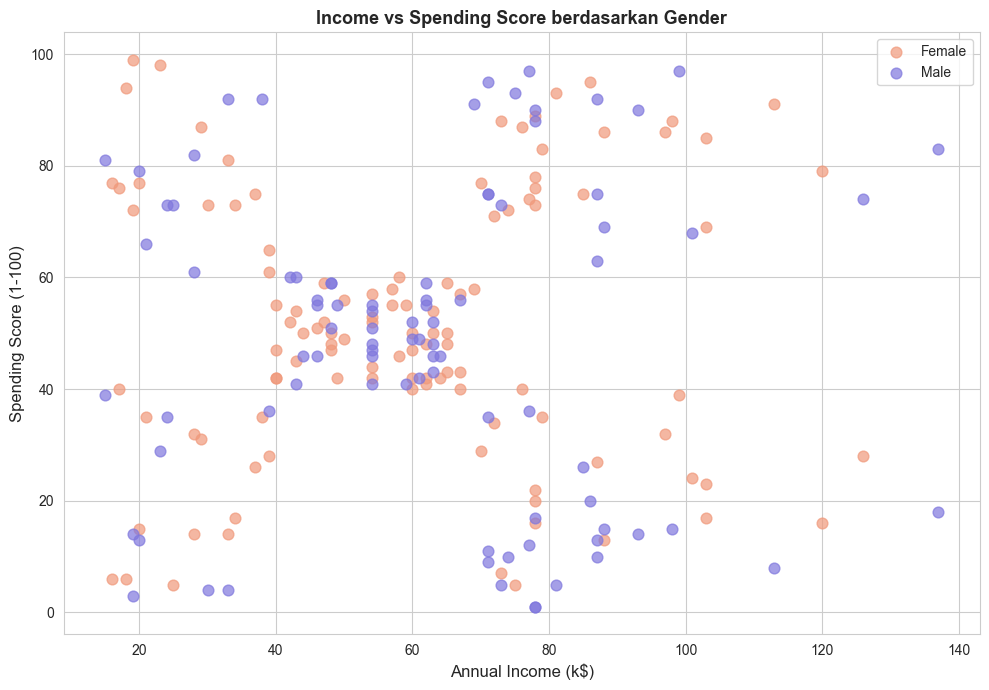


📊 Insight EDA:
- Tidak ada missing values maupun data duplikat
- Distribusi Age & Income cukup merata
- Terlihat pola pengelompokan natural pada scatter Income vs Spending
- Tidak ada korelasi kuat antar fitur — cocok untuk clustering



In [8]:
plt.figure(figsize=(10, 7))

colors_gender = {'Male': '#7F77DD', 'Female': '#F0997B'}
for gender, group in df.groupby('Gender'):
    plt.scatter(group['Annual Income (k$)'], group['Spending Score (1-100)'],
                label=gender, color=colors_gender[gender], alpha=0.7, s=60)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Income vs Spending Score berdasarkan Gender', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📊 Insight EDA:
- Tidak ada missing values maupun data duplikat
- Distribusi Age & Income cukup merata
- Terlihat pola pengelompokan natural pada scatter Income vs Spending
- Tidak ada korelasi kuat antar fitur — cocok untuk clustering
""")

## Preprocessing
Tahap membersihkan dan menyiapkan data agar siap dilatih oleh model clustering.

In [9]:
# Pilih fitur yang relevan untuk clustering
# CustomerID tidak dipakai (hanya ID)
# Gender tidak dipakai (tidak numerik)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df_features = df[features].copy()

print(f"Fitur yang digunakan : {features}")
print(f"Shape data fitur     : {df_features.shape}")
df_features.head()

Fitur yang digunakan : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape data fitur     : (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [10]:
before = len(df_features)
df_features = df_features.dropna()
after = len(df_features)

removed = before - after
if removed > 0:
    print(f"⚠️  {removed} baris dihapus karena missing values")
else:
    print(f"✅ Tidak ada missing values — semua {after} baris dipertahankan")

✅ Tidak ada missing values — semua 200 baris dipertahankan


In [11]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(scaled_array, columns=features)

print("Statistik setelah StandardScaler:")
print(df_scaled.describe().round(3))
print()
print("✅ Scaling berhasil — mean ≈ 0, std ≈ 1")

Statistik setelah StandardScaler:
           Age  Annual Income (k$)  Spending Score (1-100)
count  200.000             200.000                 200.000
mean    -0.000              -0.000                  -0.000
std      1.003               1.003                   1.003
min     -1.496              -1.739                  -1.910
25%     -0.725              -0.728                  -0.600
50%     -0.205               0.036                  -0.008
75%      0.728               0.666                   0.885
max      2.236               2.918                   1.894

✅ Scaling berhasil — mean ≈ 0, std ≈ 1


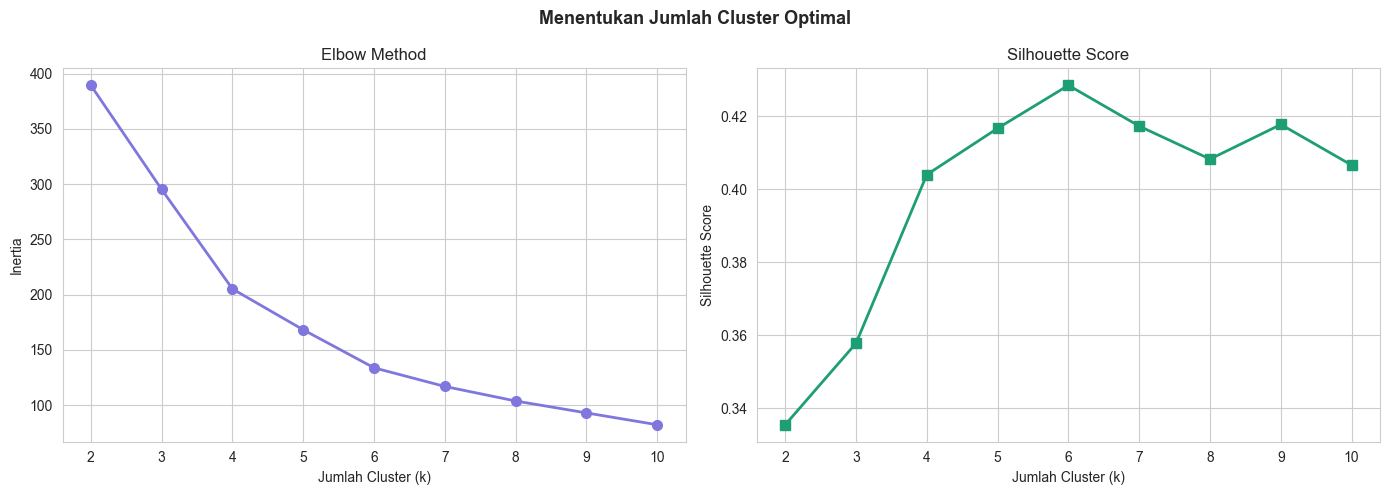

📊 K optimal berdasarkan Silhouette Score : k=6
Silhouette Score terbaik                  : 0.4284


In [12]:
inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(df_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=13, fontweight='bold')

ax1.plot(k_range, inertia_list, 'o-', color='#7F77DD', linewidth=2, markersize=7)
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(k_range, silhouette_list, 's-', color='#1D9E75', linewidth=2, markersize=7)
ax2.set_xlabel('Jumlah Cluster (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[silhouette_list.index(max(silhouette_list))]
print(f"📊 K optimal berdasarkan Silhouette Score : k={best_k}")
print(f"Silhouette Score terbaik                  : {max(silhouette_list):.4f}")

In [13]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_features['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"✅ K-Means berhasil dijalankan dengan k={OPTIMAL_K}")
print(f"\nDistribusi Cluster:")
print(df_features['Cluster'].value_counts().sort_index())
print(f"\nInertia    : {kmeans.inertia_:.2f}")
print(f"Silhouette : {silhouette_score(df_scaled, df_features['Cluster']):.4f}")

✅ K-Means berhasil dijalankan dengan k=5

Distribusi Cluster:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Inertia    : 168.25
Silhouette : 0.4166


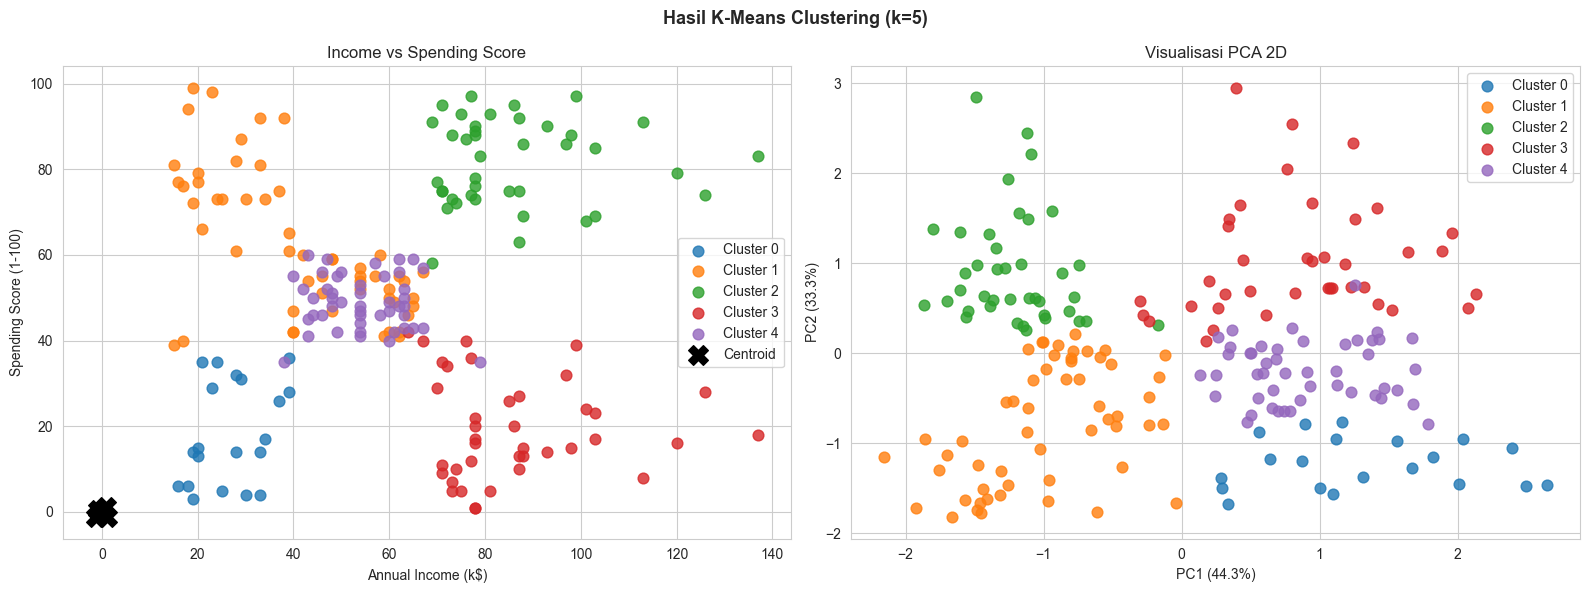

✅ Visualisasi clustering tersimpan


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Hasil K-Means Clustering (k={OPTIMAL_K})', fontsize=13, fontweight='bold')

palette = sns.color_palette('tab10', OPTIMAL_K)

# Scatter: Income vs Spending
for cluster_id in range(OPTIMAL_K):
    mask = df_features['Cluster'] == cluster_id
    ax1.scatter(df_features.loc[mask, 'Annual Income (k$)'],
                df_features.loc[mask, 'Spending Score (1-100)'],
                color=palette[cluster_id], label=f'Cluster {cluster_id}',
                s=60, alpha=0.8)
ax1.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2],
            color='black', marker='X', s=200, label='Centroid', zorder=5)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')
ax1.set_title('Income vs Spending Score')
ax1.legend()

# PCA 2D
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)
for cluster_id in range(OPTIMAL_K):
    mask = df_features['Cluster'] == cluster_id
    ax2.scatter(pca_result[mask, 0], pca_result[mask, 1],
                color=palette[cluster_id], label=f'Cluster {cluster_id}',
                s=60, alpha=0.8)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('Visualisasi PCA 2D')
ax2.legend()

plt.tight_layout()
plt.savefig('clustering_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi clustering tersimpan")

In [16]:
cluster_profile = df_features.groupby('Cluster')[features].mean().round(2)
cluster_profile['Jumlah'] = df_features['Cluster'].value_counts().sort_index()

print("=" * 60)
print("PROFIL RATA-RATA SETIAP CLUSTER")
print("=" * 60)
print(cluster_profile.to_string())
print("""
📋 Interpretasi:
  Cluster 0: Low income, low spending    → Hemat
  Cluster 1: Low income, high spending   → Boros
  Cluster 2: High income, high spending  → Premium
  Cluster 3: High income, low spending   → Konservatif
  Cluster 4: Mid income, mid spending    → Rata-rata
""")

PROFIL RATA-RATA SETIAP CLUSTER
           Age  Annual Income (k$)  Spending Score (1-100)  Jumlah
Cluster                                                           
0        46.25               26.75                   18.35      20
1        25.19               41.09                   62.24      54
2        32.88               86.10                   81.53      40
3        39.87               86.10                   19.36      39
4        55.64               54.38                   48.85      47

📋 Interpretasi:
  Cluster 0: Low income, low spending    → Hemat
  Cluster 1: Low income, high spending   → Boros
  Cluster 2: High income, high spending  → Premium
  Cluster 3: High income, low spending   → Konservatif
  Cluster 4: Mid income, mid spending    → Rata-rata



In [17]:
import os

os.makedirs('./mall_customers_preprocessing', exist_ok=True)

# Simpan tanpa cluster (untuk training)
df_scaled_only = df_scaled.copy()
df_scaled_only.to_csv('./mall_customers_preprocessing/mall_customers_preprocessing.csv', index=False)

# Simpan dengan cluster (untuk referensi)
df_features.to_csv('./mall_customers_preprocessing/mall_customers_with_cluster.csv', index=False)

print("✅ File tersimpan:")
print("  - mall_customers_preprocessing.csv  (untuk training)")
print("  - mall_customers_with_cluster.csv   (untuk referensi)")
print(f"\nShape data preprocessing: {df_scaled_only.shape}")
df_scaled_only.head()

✅ File tersimpan:
  - mall_customers_preprocessing.csv  (untuk training)
  - mall_customers_with_cluster.csv   (untuk referensi)

Shape data preprocessing: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## Ringkasan Eksperimen

| Tahap | Keterangan |
|-------|------------|
| Dataset | Mall Customer Segmentation (200 baris, 5 kolom) |
| Fitur yang digunakan | Age, Annual Income, Spending Score |
| Missing values | Tidak ada |
| Duplikasi | Tidak ada |
| Scaling | StandardScaler (mean=0, std=1) |
| Algoritma | K-Means Clustering |
| Jumlah Cluster | 5 (berdasarkan Elbow + Silhouette) |
| Silhouette Score | 0.4166 |
| Output | mall_customers_preprocessing.csv |

## Insight
- Cluster 2 & 3 punya income sama ($86k) tapi spending berbeda jauh
- Cluster 1 didominasi pelanggan muda (25th) dengan spending tinggi
- Cluster 4 adalah kelompok terbesar (47 orang) dengan profil rata-rata

**Langkah selanjutnya:** Konversi pipeline ini ke `automate_AnggaMaulana.py`